In [1]:
!pip install python-Levenshtein

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

# --- Imports ---
from transformers import T5Tokenizer, T5ForConditionalGeneration
from scripts.dataset.COGSDataset import COGSDataset
from scripts.util.constants import DEVICE, SAMPLE_SIZE
from scripts.util.getters import get_dataset_paths
from scripts.util.savers import save_model, save_predictions, save_metrics
from scripts.core.train import train
from scripts.core.test import test
from scripts.metrics.visuals import plot_metrics_table, plot_metrics_bar, compare_test_gen_metrics
from scripts.util.clear_memory import clear_memory

In [3]:
# --- Config ---
model_name = "t5-small"
enhancement = "raw"
role_flag = False

In [4]:
# --- Load tokenizer and model ---
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thouroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [5]:
# --- Load datasets ---
paths = get_dataset_paths(enhancement)

train_dataset = COGSDataset(paths["train"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=False, role_flag=role_flag)
dev_dataset   = COGSDataset(paths["dev"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=False, role_flag=role_flag)
test_dataset  = COGSDataset(paths["test"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=False, role_flag=role_flag)
gen_dataset   = COGSDataset(paths["gen"], tokenizer, sample_frac=SAMPLE_SIZE, inject_roles=False, role_flag=role_flag)

In [6]:
# --- Train ---
model, tokenizer = train(model, tokenizer, train_dataset, dev_dataset, enhancement=enhancement, role_flag=role_flag)
save_model(model, tokenizer, model_name, enhancement)

[DEBUG] raw Train Loss (Epoch 1): 1.5415
[DEBUG] raw Dev Eval (Epoch 1):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0010
  edit_distance_avg: 97.7067
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9767
[DEBUG] raw Train Loss (Epoch 2): 1.0185
[DEBUG] raw Dev Eval (Epoch 2):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0012
  edit_distance_avg: 101.3500
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9667
[DEBUG] raw Train Loss (Epoch 3): 0.7887
[DEBUG] raw Dev Eval (Epoch 3):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0010
  edit_distance_avg: 105.4267
  predicate_accuracy: 0.0000
  valid_logical_form_ratio: 0.9333
[DEBUG] raw Train Loss (Epoch 4): 0.6291
[DEBUG] raw Dev Eval (Epoch 4):
  precision: 0.0000
  recall: 0.0000
  f1: 0.0000
  bleu: 0.0017
  edit_distance_avg: 106.2233
  predicate_accuracy: 0.0007
  valid_logical_form_ratio: 0.8433
[DEBUG] raw Train Loss (Epoch 5): 0.5096
[DEBUG] raw Dev Eval (Epoch 5):


[INFO] Predictions saved to: predictions/raw/t5-small_test_predictions.txt
[INFO] Metrics saved to: results/raw/t5-small_test_metrics.csv
[DEBUG] raw Test Eval:
  precision: 0.0117
  recall: 0.0050
  f1: 0.0067
  bleu: 0.0057
  edit_distance_avg: 110.5467
  predicate_accuracy: 0.0064
  valid_logical_form_ratio: 0.8067


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.0117,0.0050,0.0067,0.0057,110.5467,0.0064,0.8067


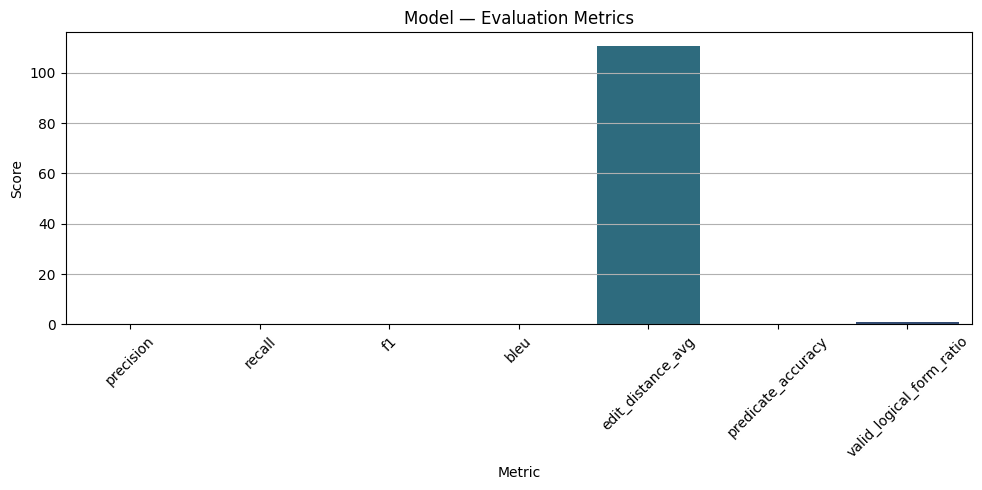

In [7]:
# --- Evaluate: Test ---
test_preds, test_metrics = test(model, tokenizer, test_dataset, model_name, enhancement, dataset_type="test")
plot_metrics_table(f"results/{enhancement}/{model_name}_test_metrics.csv")
plot_metrics_bar(f"results/{enhancement}/{model_name}_test_metrics.csv")

[INFO] Predictions saved to: predictions/raw/t5-small_gen_predictions.txt
[INFO] Metrics saved to: results/raw/t5-small_gen_metrics.csv
[DEBUG] raw Gen Eval:
  precision: 0.0086
  recall: 0.0048
  f1: 0.0059
  bleu: 0.0047
  edit_distance_avg: 161.9286
  predicate_accuracy: 0.0057
  valid_logical_form_ratio: 0.8395


,precision,recall,f1,bleu,edit_distance_avg,predicate_accuracy,valid_logical_form_ratio
0,0.0086,0.0048,0.0059,0.0047,161.9286,0.0057,0.8395


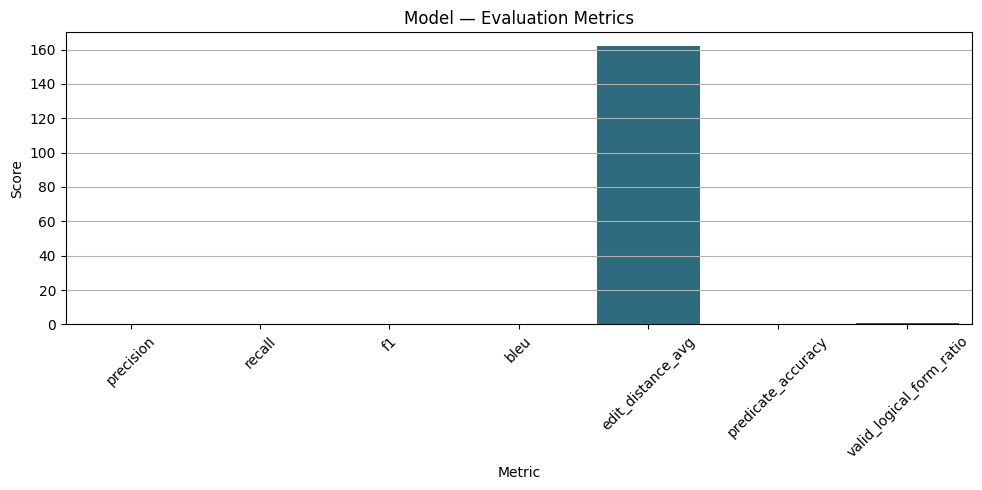

In [8]:
# --- Evaluate: Gen ---
gen_preds, gen_metrics = test(model, tokenizer, gen_dataset, model_name, enhancement, dataset_type="gen")
plot_metrics_table(f"results/{enhancement}/{model_name}_gen_metrics.csv")
plot_metrics_bar(f"results/{enhancement}/{model_name}_gen_metrics.csv")

,Test,Gen
precision,0.0117,0.0086
recall,0.0050,0.0048
f1,0.0067,0.0059
bleu,0.0057,0.0047
edit_distance_avg,110.5467,161.9286
predicate_accuracy,0.0064,0.0057
valid_logical_form_ratio,0.8067,0.8395


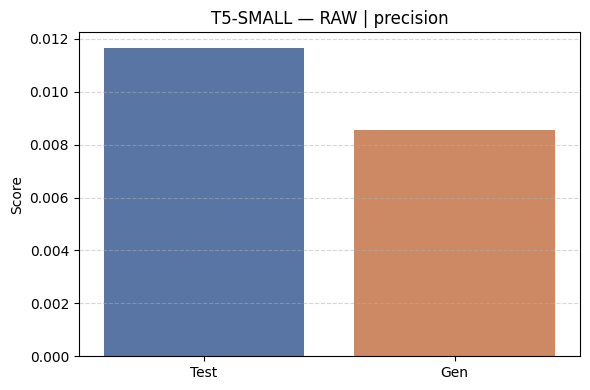

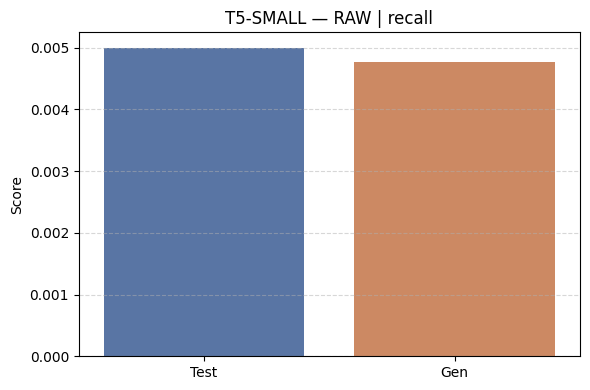

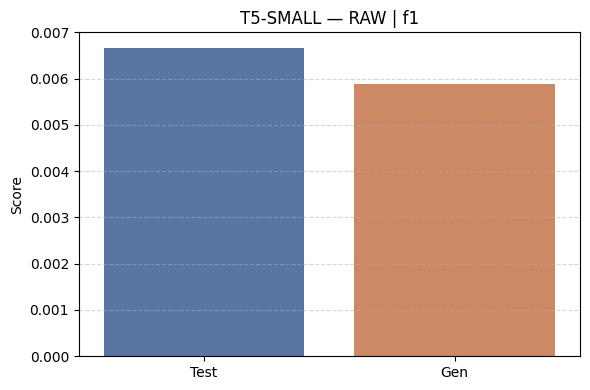

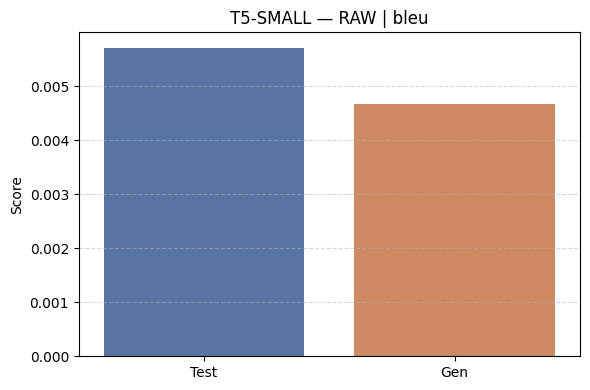

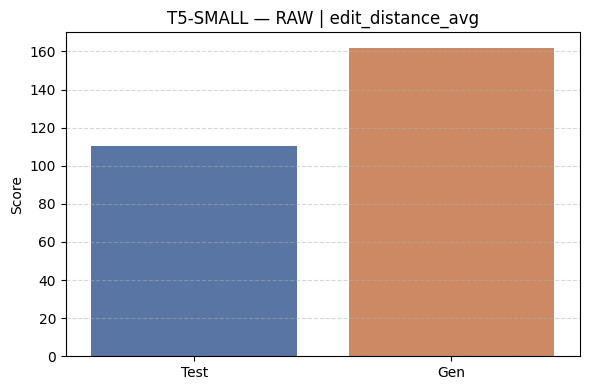

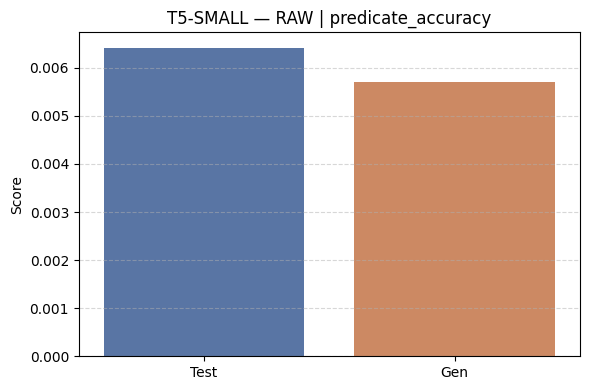

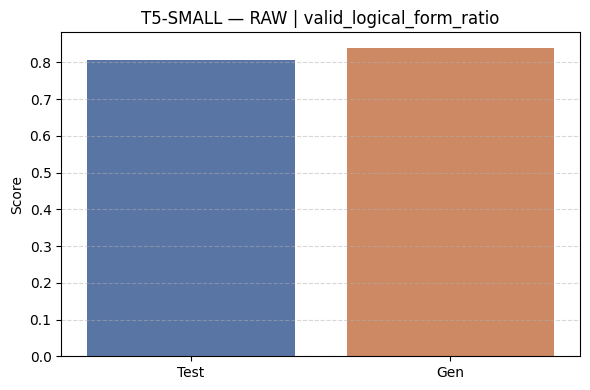

In [9]:
# --- Compare Test vs Gen Results
compare_test_gen_metrics(model_name, enhancement)

In [10]:
# --- Cleanup ---
clear_memory(model)